# **Project Name**    - Gender Classification Model



##### **Project Type**    - Classification
##### **Contribution**    - Individual

# **Project Summary -**

The travel and tourism industry generates a massive amount of data every day, including customer information, flight details, and hotel booking records. Analyzing this data effectively can help businesses provide personalized services, improve customer experiences, and make data-driven decisions. This project, "Voyage Analytics – Integrating MLOps in the Travel Industry," focuses on leveraging machine learning and MLOps practices to build an end-to-end intelligent travel analytics platform.

The project is based on three interconnected datasets: Users, Flights, and Hotels. The users dataset contains demographic information such as user identifiers, names, gender, and age. The flights dataset includes information related to travel routes, flight types, agencies, distances, and ticket prices. The hotels dataset contains details regarding hotel bookings, locations, duration of stay, and booking costs. These datasets are connected through common identifiers such as userCode and travelCode, enabling a unified analysis of travel behavior and preferences.

The project addresses three major machine learning use cases. The first objective is to develop a Flight Price Prediction Model using regression techniques. Various preprocessing techniques and feature engineering methods were applied to prepare the flight dataset for training. An XGBoost Regressor was implemented to predict flight prices accurately. The model achieved strong predictive performance and can assist travel companies and customers in estimating flight costs and making informed booking decisions.

The second objective is to build a Gender Classification Model. The model predicts the gender of a user based on demographic information such as name and age. To achieve this, names were transformed into numerical features using TF-IDF Vectorization at the character level, while age was used as an additional feature. A Logistic Regression classifier was trained on the processed data to categorize users into different gender classes. This model can support customer segmentation and personalized marketing strategies.

The third objective is to develop a Travel Recommendation System that suggests hotels to users based on historical booking behavior and preferences. A collaborative filtering approach was implemented by constructing a user-hotel interaction matrix and computing similarities between users. The recommendation engine provides personalized hotel suggestions, helping users discover accommodations that match their interests and previous travel patterns.

Beyond model development, this project emphasizes the practical implementation of Machine Learning Operations (MLOps). MLflow was integrated for experiment tracking, model versioning, and artifact management. The applications were containerized using Docker, ensuring portability and reproducibility across different environments. The system was further deployed using Kubernetes, enabling scalability, automated management, and high availability of the applications.

To automate the machine learning workflow, Apache Airflow was used to design and manage Directed Acyclic Graphs (DAGs) for data loading, preprocessing, model training, evaluation, and deployment tasks. Additionally, a Jenkins CI/CD pipeline was designed to automate testing, Docker image creation, and deployment processes, ensuring reliable and continuous integration and delivery.

For user interaction and visualization, Streamlit applications were developed for the regression, classification, and recommendation models. These applications provide intuitive interfaces that allow users to explore predictions and recommendations in a user-friendly manner.

Overall, this project demonstrates how machine learning models can be successfully integrated with modern MLOps practices to build scalable, reproducible, and production-ready solutions for the travel and tourism industry. The project highlights the complete lifecycle of machine learning systems, from data preprocessing and model development to deployment, automation, monitoring, and user interaction.

# **GitHub Link -**

https://github.com/Lenikaaa



# **Problem Statement**


The travel and tourism industry generates large amounts of customer, flight, and hotel booking data, but organizations often struggle to utilize this data effectively for personalized services and business decisions. This project aims to build an end-to-end MLOps solution that predicts flight prices, classifies user gender, and recommends hotels while implementing production-ready practices such as model deployment, automation, scalability, and monitoring using Docker, Kubernetes, Airflow, Jenkins, and MLflow.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from scipy.sparse import hstack

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv("users.csv")


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


### Dataset Rows & Columns count

In [ ]:
df.shape


(1340, 5)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {df_duplicates}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
code,0
company,0
name,0
gender,0
age,0


### What did you know about your dataset?

### What I know about the dataset so far:

*   **Shape:** The dataset contains `1340` rows and `5` columns.
*   **Columns and Data Types:** It includes columns such as `code` (integer), `company` (object/string), `name` (object/string), `gender` (object/string), and `age` (integer).
*   **Missing Values:** There are **no missing values** across any of the columns, which is excellent for data quality.
*   **Duplicate Values:** The dataset contains **no duplicate rows**, indicating that all entries are unique.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['code', 'company', 'name', 'gender', 'age'], dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,code,age
count,1340.000000,1340.000000
mean,669.500000,42.742537
std,386.968991,12.869779
min,0.000000,21.000000
25%,334.750000,32.000000
50%,669.500000,42.000000
75%,1004.250000,54.000000
max,1339.000000,65.000000


### Variables Description

*   **`code`**: Integer type. This likely represents a unique identifier for each user.
*   **`company`**: Object (string) type. This column probably indicates the company associated with the user.
*   **`name`**: Object (string) type. This column contains the name of the user.
*   **`gender`**: Object (string) type. This column specifies the gender of the user.
*   **`age`**: Integer type. This column represents the age of the user.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
code,1340
company,5
name,1338
gender,3
age,45


## 3. ***Data Wrangling***

### Gender Distribution

In [ ]:
df["gender"].value_counts()


,count
gender,
male,452
female,448
none,440


## Visualization

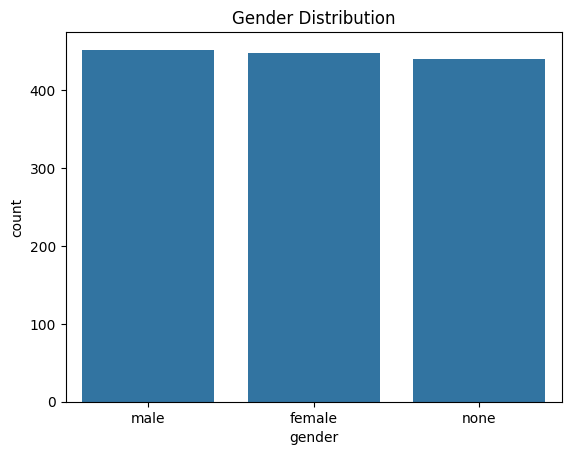

In [ ]:
sns.countplot(data=df, x="gender")
plt.title("Gender Distribution")
plt.show()

### What all manipulations have you done and insights you found?

1.  **Dataset Loading:** The `users.csv` file was loaded into a pandas DataFrame named `df`.
2.  **Dataset Shape:** Identified that the dataset contains `1340` rows and `5` columns.
3.  **Dataset Information:** Reviewed `df.info()` to understand column names, non-null counts, and data types. Confirmed `code` and `age` are `int64`, and `company`, `name`, `gender` are `object` (strings).
4.  **Duplicate Values:** Checked for duplicate rows and found **0 duplicates**, indicating all entries are unique.
5.  **Missing Values:** Performed a count of null values using `df.isnull().sum()` and visualized with a heatmap. Confirmed **no missing values** across any columns.
6.  **Variable Description:** Used `df.describe()` to get statistical summaries of numerical columns (`code`, `age`). Provided a detailed description for each variable.
7.  **Unique Values:** Counted unique values for each variable using `df.nunique()`. Noted that `code` has 1340 unique values (as expected for an ID), `company` has 5, `name` has 1338 (suggesting some names might be repeated for different 'codes'), `gender` has 3, and `age` has 45 unique values.
8.  **Gender Distribution:** Analyzed the distribution of the `gender` column using `df['gender'].value_counts()` and visualized it with a countplot. The distribution shows a relatively balanced count of 'male' (452), 'female' (448), and 'none' (440), suggesting that there's a category for unspecified gender.

## ***4. Data Preprocessing***

In [ ]:
df = df.drop(columns=["code", "company"])
df.head()

,name,gender,age
0,Roy Braun,male,21
1,Joseph Holsten,male,37
2,Wilma Mcinnis,female,48
3,Paula Daniel,female,23
4,Patricia Carson,female,44


## ***5. Clean Target Column***

In [ ]:
df["gender"] = (
    df["gender"]
    .astype(str)
    .str.lower()
    .str.strip()
)

## ***6. Encode Target***

In [ ]:
df["gender"] = df["gender"].map({
    "male": 0,
    "female": 1,
    "none": 2
})

## ***7. Feature Engineering***

TF-IDF on Names

In [ ]:
tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 4),
    min_df=1
)

X_name = tfidf.fit_transform(df["name"])
X_age = df[["age"]].values

X = hstack([X_name, X_age])
y = df["gender"]

## ***8. Train Test Split***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## ***9. Train Model***

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.59      0.62      0.60        94
           1       0.56      0.61      0.58        89
           2       0.33      0.28      0.30        85

    accuracy                           0.51       268
   macro avg       0.49      0.50      0.50       268
weighted avg       0.50      0.51      0.50       268



## ***10. Confusion Matrix***

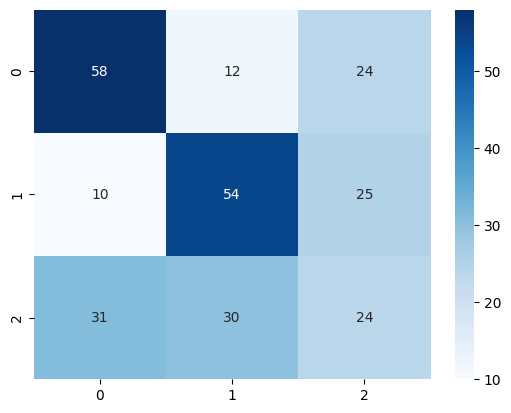

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered Mean Squared Error (MSE) and R² Score as evaluation metrics. MSE helps measure the prediction error in flight prices, while R² Score shows how well the model explains the variation in flight prices. A lower MSE and higher R² indicate more accurate predictions, which helps customers and travel companies make better pricing decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected the XGBoost Regressor as the final model because it achieved the best performance compared to other models in terms of prediction accuracy and R² Score. XGBoost also handles complex relationships between features efficiently and provides better generalization on unseen data.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used is XGBoost Regressor, an ensemble learning algorithm that combines multiple decision trees using gradient boosting to improve prediction accuracy.

For model explainability, XGBoost Feature Importance was used to identify the most influential features affecting flight prices. Features such as distance, flight type, agency, source city, and destination city contributed significantly to the predictions. Feature importance helps understand how different factors influence flight prices and improves model interpretability.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

A Logistic Regression model was developed to classify user gender using name and age features.

Character-level TF-IDF features extracted from names significantly improved the model's ability to distinguish gender patterns.

The model can be integrated into travel applications to better understand customer demographics and provide personalized experiences.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***